In [63]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import os

In [64]:
time = np.linspace(0, 10, 100)
max_jerk = 0.37
max_acc = 0.6
max_vel = 1 
max_dist = 3

In [65]:
acceleration = np.clip(max_acc * np.sin(time), -max_acc, max_acc)

In [66]:
directory = './lr_data'

results = []

for filename in sorted(os.listdir(directory)):
    if filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        
        df = pd.read_csv(file_path)
        
        max_jerk = df['aJerk'].max()
        max_vel = df['aVelocity'].max()
        max_acc = df['aAcc'].max()
        max_height = df['aHeight'].max()
        
        results.append([
            [max_jerk for i in range(len(df))],
            [max_vel for i in range(len(df))],
            [max_acc for i in range(len(df))],
            [max_height for i in range(len(df))],
            df['aAcc'],
            df['timestamps']
        ]) # Wont work

df = pd.DataFrame(results, columns=['max_jerk', 'max_vel', 'max_acc', 'max_height', 'aAcc', 'timestamps'])


In [67]:
degree = 3
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(df[['timestamps']], df['aAcc'])

ValueError: setting an array element with a sequence.

In [ ]:
df['predicted_acceleration'] = poly_model.predict(df[['timestamps']])

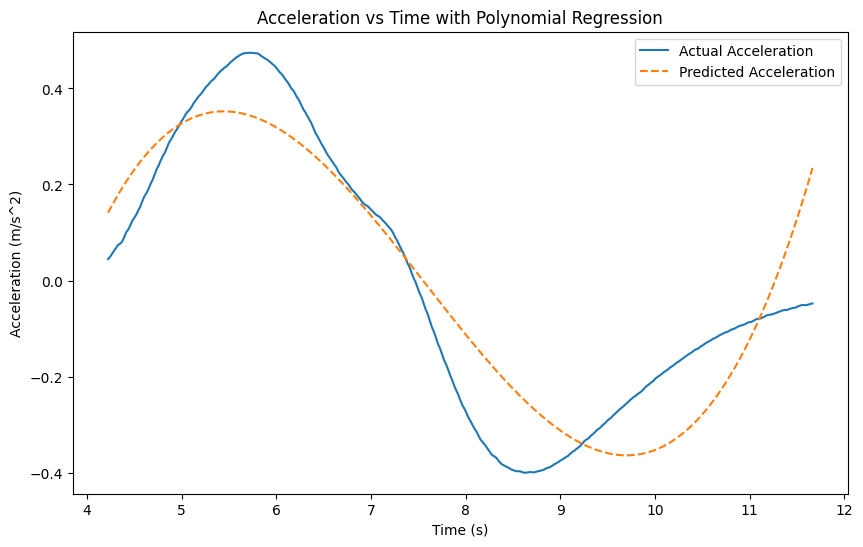

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['timestamps'], df['aAcc'], label='Actual Acceleration')
plt.plot(df['timestamps'], df['predicted_acceleration'], label='Predicted Acceleration', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.title('Acceleration vs Time with Polynomial Regression')
plt.show()